===== BASIC STATS =====
VLM depth min/max (valid): 0.0 19.906298
noVLM depth min/max (valid): 0.0 19.903051
Valid cell count: 353116

===== ΔA COUNTS (hc = 1.25 m) =====
ΔA = +1 (newly flooded due to VLM): 4509
ΔA = -1 (lost flooding with VLM)  : 1
ΔA =  0 (unchanged)               : 348606

Saved:
   D:\Phd Research\Final_Raster\VLM_only_inundation_increase_hc1p25.tif
   D:\Phd Research\Final_Raster\dA_100yr_VLM_minus_noVLM_hc1p25.tif


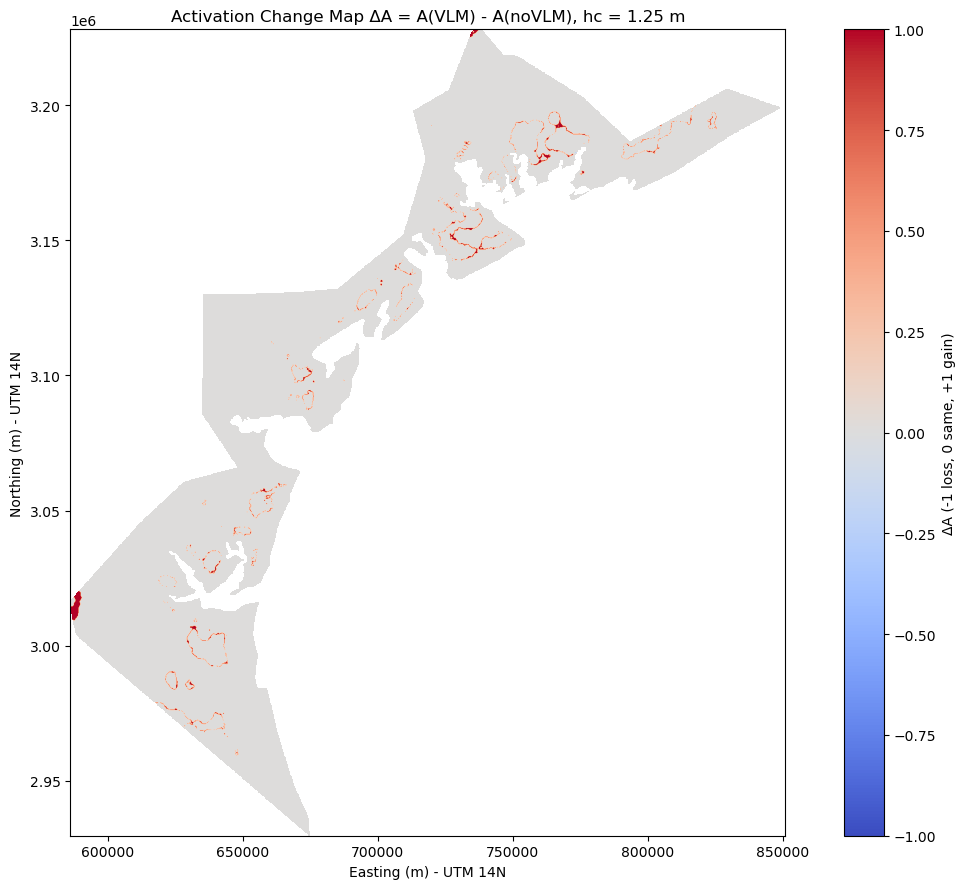

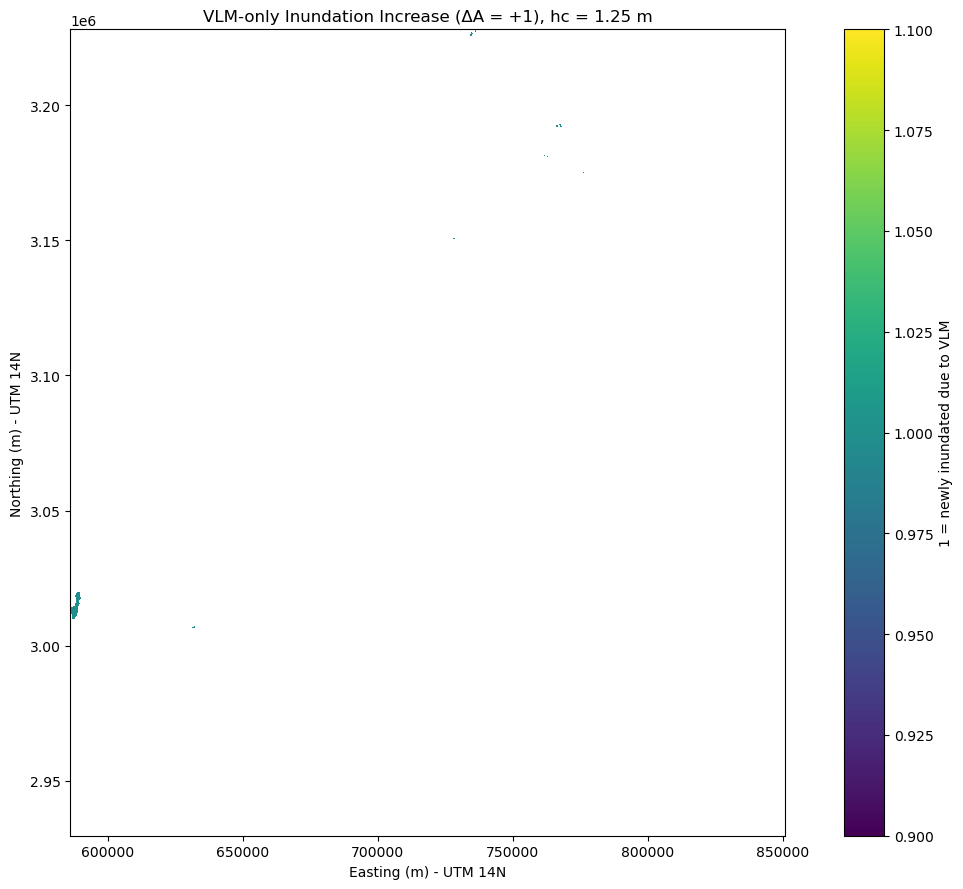

In [4]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt

# ===================== USER INPUT =====================
r_vlm   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"
r_novlm = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_wo_VLM_stat.tif"

hc = 1.25  # meters

out_inc = r"D:\Phd Research\Final_Raster\VLM_only_inundation_increase_hc1p25.tif"
out_dA  = r"D:\Phd Research\Final_Raster\dA_100yr_VLM_minus_noVLM_hc1p25.tif"
# ======================================================

def read_float(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        prof = src.profile
        nd = src.nodata
        bounds = src.bounds
    if nd is not None:
        arr = np.where(arr == nd, np.nan, arr)
    arr = np.where(np.isfinite(arr), arr, np.nan)
    return arr, prof, bounds

def match_to_template(src_arr, src_prof, tmpl_prof):
    same = (
        src_prof["crs"] == tmpl_prof["crs"]
        and src_prof["transform"] == tmpl_prof["transform"]
        and src_prof["width"] == tmpl_prof["width"]
        and src_prof["height"] == tmpl_prof["height"]
    )
    if same:
        return src_arr

    dst = np.full((tmpl_prof["height"], tmpl_prof["width"]), np.nan, dtype="float32")
    reproject(
        source=src_arr,
        destination=dst,
        src_transform=src_prof["transform"],
        src_crs=src_prof["crs"],
        dst_transform=tmpl_prof["transform"],
        dst_crs=tmpl_prof["crs"],
        resampling=Resampling.bilinear,
        src_nodata=np.nan,
        dst_nodata=np.nan,
    )
    return dst

# ---------- Read rasters ----------
vlm, prof, bounds = read_float(r_vlm)
novlm, prof_n, _  = read_float(r_novlm)

# Make sure same grid
novlm = match_to_template(novlm, prof_n, prof)

valid = np.isfinite(vlm) & np.isfinite(novlm)

print("===== BASIC STATS =====")
print("VLM depth min/max (valid):", np.nanmin(vlm[valid]), np.nanmax(vlm[valid]))
print("noVLM depth min/max (valid):", np.nanmin(novlm[valid]), np.nanmax(novlm[valid]))
print("Valid cell count:", int(np.sum(valid)))

# ---------- Step 1: Binary activation ----------
A_vlm   = np.zeros(vlm.shape, dtype=np.int8)
A_novlm = np.zeros(vlm.shape, dtype=np.int8)
A_vlm[valid]   = (vlm[valid]   >= hc).astype(np.int8)
A_novlm[valid] = (novlm[valid] >= hc).astype(np.int8)

# ---------- Step 2: ΔA ----------
dA = np.full(vlm.shape, -128, dtype=np.int8)  # nodata
dA[valid] = (A_vlm[valid] - A_novlm[valid]).astype(np.int8)

n_gain = int(np.sum((dA ==  1) & valid))
n_loss = int(np.sum((dA == -1) & valid))
n_same = int(np.sum((dA ==  0) & valid))

print("\n===== ΔA COUNTS (hc = %.2f m) =====" % hc)
print("ΔA = +1 (newly flooded due to VLM):", n_gain)
print("ΔA = -1 (lost flooding with VLM)  :", n_loss)
print("ΔA =  0 (unchanged)               :", n_same)

# ---------- Create VLM-only increase mask ----------
inc = np.full(vlm.shape, -128, dtype=np.int8)
inc[(dA == 1) & valid] = 1

# ---------- Save rasters ----------
prof_int = prof.copy()
prof_int.update(dtype=rasterio.int8, nodata=-128, count=1, compress="LZW")

with rasterio.open(out_inc, "w", **prof_int) as dst:
    dst.write(inc, 1)

with rasterio.open(out_dA, "w", **prof_int) as dst:
    dst.write(dA, 1)

print("\nSaved:")
print("  ", out_inc)
print("  ", out_dA)

# ---------- Plot ΔA map (shows -1,0,+1) ----------
extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)

plt.figure(figsize=(12, 9))
plot_da = np.where(valid, dA.astype("float32"), np.nan)
im = plt.imshow(plot_da, extent=extent, origin="upper", vmin=-1, vmax=1, cmap="coolwarm")
plt.title(f"Activation Change Map ΔA = A(VLM) - A(noVLM), hc = {hc} m")
plt.xlabel("Easting (m) - UTM 14N")
plt.ylabel("Northing (m) - UTM 14N")
plt.colorbar(im, label="ΔA (-1 loss, 0 same, +1 gain)")
plt.tight_layout()
plt.show()

# ---------- Plot ONLY gain cells (ΔA=+1) ----------
plt.figure(figsize=(12, 9))
plot_inc = np.where(inc == 1, 1.0, np.nan)
# If there are no gain cells, warn clearly.
if np.all(np.isnan(plot_inc)):
    print("\nNOTE: No ΔA=+1 cells found at hc=%.2f m. Try a smaller threshold (e.g., 0.1 m) to reveal marginal gains." % hc)

im2 = plt.imshow(plot_inc, extent=extent, origin="upper", cmap="viridis")
plt.title(f"VLM-only Inundation Increase (ΔA = +1), hc = {hc} m")
plt.xlabel("Easting (m) - UTM 14N")
plt.ylabel("Northing (m) - UTM 14N")
plt.colorbar(im2, label="1 = newly inundated due to VLM")
plt.tight_layout()
plt.show()
